<a href="https://colab.research.google.com/github/Vanshraj30/ML-Traffic-Prediction/blob/main/Traffic_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import zipfile
import urllib.request
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [4]:
!pip install ucimlrepo

In [14]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
metro_interstate_traffic_volume = fetch_ucirepo(id=492)

# extract data (as pandas dataframes)
X = metro_interstate_traffic_volume.data.features
y = metro_interstate_traffic_volume.data.targets

# Check if it loaded correctly
X.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00


In [4]:
y.head()

,traffic_volume
0,5545
1,4516
2,4767
3,5026
4,4918


In [6]:

print("Features shape:", X.shape)
print("Targets shape:", y.shape)
print("Total records:", len(X))

Features shape: (48204, 8)
Targets shape: (48204, 1)
Total records: 48204


**EDA (Exploratory Data Analysis)**

In [15]:
df=pd.concat([X,y],axis=1)
print("Dataset Info")
df.info()
print("Summary Statistics")
df.describe()

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
Summary Statistics


,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


##**Cleaning the Data**

In [17]:
#Fill the missing holidays with None instead of leaving them blank
df['holiday']=df['holiday'].fillna('None')
#the min value of temp is 0.000 , avg is 281 and max is 310.. the data is in Kelvins... So 0 kelvin is around -273C, which is impossible
df=df[df['temp']>0]
#drop the impossible rain outlier
df=df[df['rain_1h']<9000]
#convert date_time from text to a real datetime format
df['date_time']=pd.to_datetime(df['date_time'])
#extract the hr,day and month to analyze traffic patterns over time
df['hour']=df['date_time'].dt.hour
df['day_of_week']=df['date_time'].dt.dayofweek  #0=Monday 6=Sunday
df['month']=df['date_time'].dt.month

print ("Data cleaning complete! New dataset shape:",df.shape)
df.head()

Data cleaning complete! New dataset shape: (48193, 12)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day_of_week,month
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10


#Visualization

Hour vs Traffic analyzes

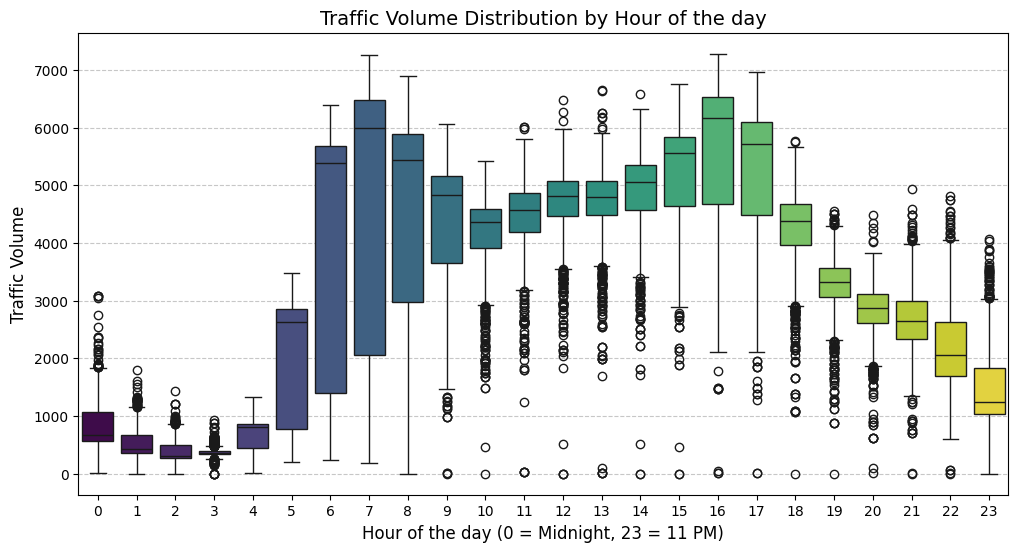

In [19]:
import matplotlib.pyplot as plt
import seaborn as sb
plt.figure(figsize=(12,6))

#Creating a box plot
sns.boxplot(x='hour',y='traffic_volume',data=df,hue='hour',palette='viridis',legend=False)

plt.title('Traffic Volume Distribution by Hour of the day',fontsize=14)
plt.xlabel('Hour of the day (0 = Midnight, 23 = 11 PM)',fontsize=12)
plt.ylabel('Traffic Volume',fontsize=12)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.show()


#The Weather Effect

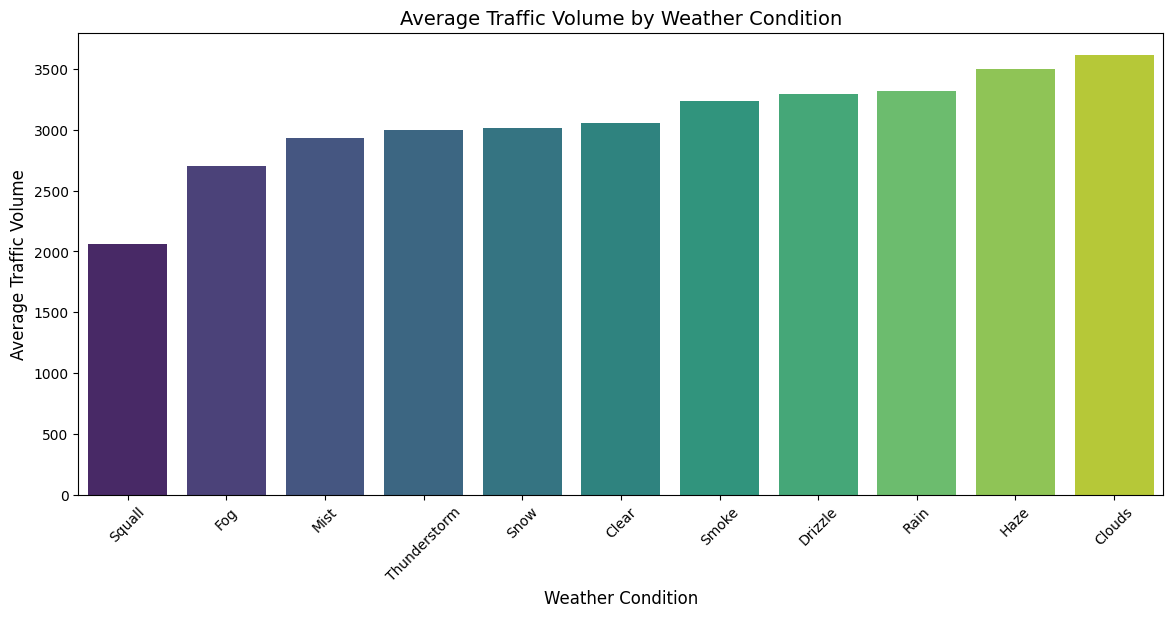

In [22]:
plt.figure(figsize=(14,6))

#calculate avg traffic volume for each weather
weather_traffic=df.groupby('weather_main')['traffic_volume'].mean().sort_values()

#creating a bar graph
sns.barplot(x=weather_traffic.index, y=weather_traffic.values, hue=weather_traffic.index, palette='viridis', legend=False)

plt.title('Average Traffic Volume by Weather Condition',fontsize=14)
plt.xlabel('Weather Condition',fontsize=12)
plt.ylabel('Average Traffic Volume',fontsize=12)
plt.xticks(rotation=45)

plt.show()

Target variable distribution

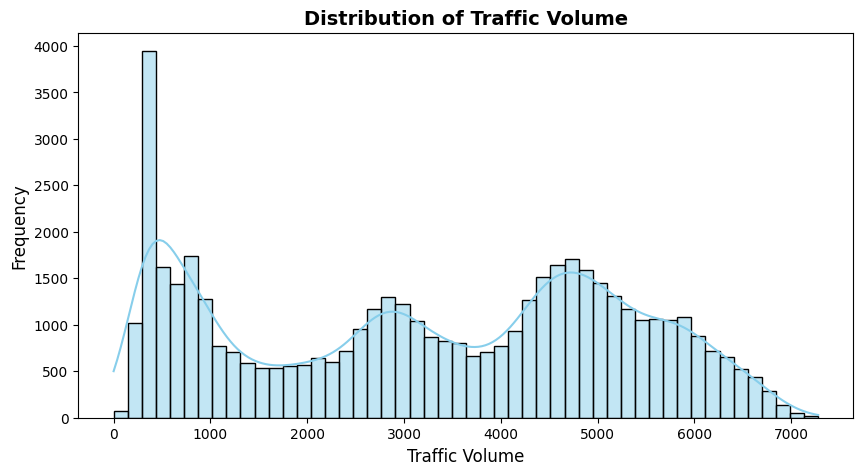

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(df['traffic_volume'],bins=50,kde=True,color='skyblue')
plt.title('Distribution of Traffic Volume',fontsize=14,fontweight='bold')
plt.xlabel('Traffic Volume',fontsize=12)
plt.ylabel('Frequency',fontsize=12)
plt.show()

Temp effect using heatmap

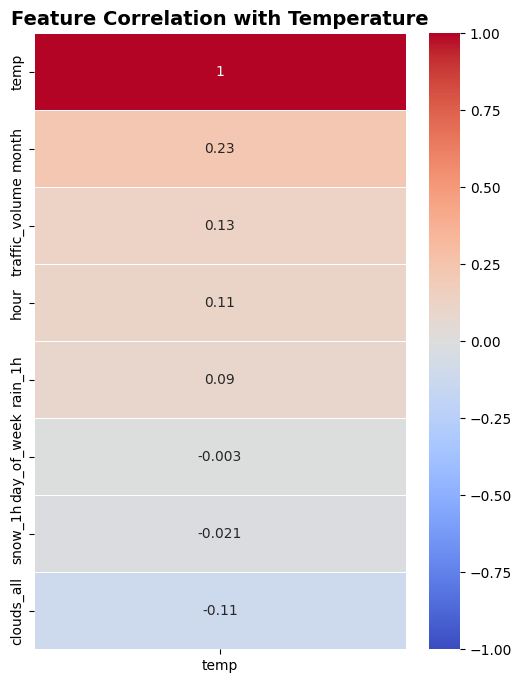

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))

# 1. Filter for only numeric columns so the math works
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
temp_corr = numeric_df.corr()[['temp']].sort_values(by='temp', ascending=False)

# 3. Create the heatmap
sns.heatmap(temp_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Feature Correlation with Temperature', fontsize=14, fontweight='bold')
plt.show()

#Encoding


in our dataset , we have 3 values categorical
*   holiday
*   weather_main
*   weather_description






In [26]:
# use OHE, instead of giving clouds 1 , rain 2 we use True/false
categorical_cols=['holiday','weather_main','weather_description']

#use pandas for directly OHE
#drop_first=true prevents a math issue called dummy variable trap
df_encoded=pd.get_dummies(df,columns=categorical_cols,drop_first=True)

print("Old Shape:",df.shape)
print("New Shape:",df_encoded.shape)
df_encoded.head()


Old Shape: (48193, 12)
New Shape: (48193, 67)


,temp,rain_1h,snow_1h,clouds_all,date_time,traffic_volume,hour,day_of_week,month,holiday_Columbus Day,...,weather_description_sleet,weather_description_smoke,weather_description_snow,weather_description_thunderstorm,weather_description_thunderstorm with drizzle,weather_description_thunderstorm with heavy rain,weather_description_thunderstorm with light drizzle,weather_description_thunderstorm with light rain,weather_description_thunderstorm with rain,weather_description_very heavy rain
0,288.28,0.0,0.0,40,2012-10-02 09:00:00,5545,9,1,10,False,...,False,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,2012-10-02 10:00:00,4516,10,1,10,False,...,False,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,2012-10-02 11:00:00,4767,11,1,10,False,...,False,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,2012-10-02 12:00:00,5026,12,1,10,False,...,False,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,2012-10-02 13:00:00,4918,13,1,10,False,...,False,False,False,False,False,False,False,False,False,False


#Model Training

In [28]:
from sklearn.model_selection import train_test_split
#Define Features(X) and Target(Y)
X = df_encoded.drop(columns=['traffic_volume', 'date_time'])
y = df_encoded['traffic_volume']

#Train-test Split (80% training, 20% testing)
# using random_state to get exact same split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")


Training data shape: (38554, 65)
Testing data shape: (9639, 65)


In [29]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.2 MB/s eta 0:00:00


In [30]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.3 MB/s eta 0:00:00


In [31]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn. ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
import optuna
import warnings
warnings.filterwarnings('ignore')

In [33]:
#Training to test different regression Algorithms
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0)
}

# setting the scorecard
print(f"{'Algorithm':<20} | {'R² Score':<10} | {'RMSE (Error in Cars)'}")
print("-" * 55)

#scoring each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"{name:<20} | {r2:<10.4f} | {rmse:.2f} cars")

Algorithm            | R² Score   | RMSE (Error in Cars)
-------------------------------------------------------
Linear Regression    | 0.1642     | 1813.10 cars
Ridge Regression     | 0.1643     | 1812.98 cars
Decision Tree        | 0.9351     | 505.33 cars
Random Forest        | 0.9381     | 493.39 cars
XGBoost              | 0.9515     | 436.92 cars
LightGBM             | 0.9500     | 443.38 cars
CatBoost             | 0.9428     | 474.34 cars


#Hyperparamter Optimization

In [37]:
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        # Keep max_depth relatively low (4 to 8) to prevent overfitting
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**param)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    return rmse

print(" --- Launching Optuna Optimization for XGBoost --- ")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\n Optimization Complete!")
print("Best Parameters Found:")
for key, value in study.best_params.items():
    print(f" {key}: {value}")

[I 2026-06-24 21:39:18,180] A new study created in memory with name: no-name-82780105-5736-427a-99fb-32497257a1dd


 --- Launching Optuna Optimization for XGBoost --- 


[I 2026-06-24 21:39:21,553] Trial 0 finished with value: 480.0810478450488 and parameters: {'n_estimators': 271, 'learning_rate': 0.04266556260514266, 'max_depth': 4, 'subsample': 0.7043835103442512, 'colsample_bytree': 0.7029607528267814}. Best is trial 0 with value: 480.0810478450488.
[I 2026-06-24 21:39:22,516] Trial 1 finished with value: 471.0299054996402 and parameters: {'n_estimators': 138, 'learning_rate': 0.08667994829818464, 'max_depth': 4, 'subsample': 0.9943471645666302, 'colsample_bytree': 0.8879488390164774}. Best is trial 1 with value: 471.0299054996402.
[I 2026-06-24 21:39:23,994] Trial 2 finished with value: 485.8946484321473 and parameters: {'n_estimators': 182, 'learning_rate': 0.02486475558733672, 'max_depth': 5, 'subsample': 0.8287997687438682, 'colsample_bytree': 0.8942341173210018}. Best is trial 1 with value: 471.0299054996402.
[I 2026-06-24 21:39:26,463] Trial 3 finished with value: 457.3984518447783 and parameters: {'n_estimators': 192, 'learning_rate': 0.0214


 Optimization Complete!
Best Parameters Found:
 n_estimators: 380
 learning_rate: 0.08008942038418917
 max_depth: 8
 subsample: 0.7103129083759286
 colsample_bytree: 0.9529734406221347


#Final Traing of Model

In [39]:
final_xgb = XGBRegressor(
n_estimators=400,
learning_rate=0.09925088946645556,
max_depth=8,
subsample=0.7275726784155104,
colsample_bytree=0.9546980775774992,
random_state=42,
n_jobs =- 1

)

print(" --- Training Final Optimized XGBoost Model --- ")
final_xgb.fit(X_train, y_train)
final_preds = final_xgb.predict(X_test)
final_r2 = r2_score(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))

print(f" Final R2 Score: {final_r2:.4f}")
print(f" Final RMSE: {final_rmse:.2f} cars\n")

 --- Training Final Optimized XGBoost Model --- 
 Final R2 Score: 0.9594
 Final RMSE: 399.76 cars



#Exporting the Model

In [40]:
#exporting the trained model to a file
model_filename = 'traffic_xgboost_model. joblib'
joblib.dump(final_xgb, model_filename)

print(f" Model successfully saved to {model_filename}")


 Model successfully saved to traffic_xgboost_model. joblib
